# AIVLE스쿨 2차 미니프로젝트: 신규 아파트 주차 수요 예측

<img src = "https://github.com/Jangrae/img/blob/master/parking.png?raw=true" width=800, align="left"/>

# 단계 2: 탐색적 데이터 분석

## [미션]

단계1 에서 생성한 데이터에 대해서 탐색적 분석을 수행합니다.

1) 단변량 분석
    - 숫자형, 범주형 변수에 맞게 데이터를 탐색하며 비즈니스적 의미를 파악합니다.
2) 이변량 분석
    - 숫자형 변수 → 실차량수 상관관계를 분석합니다.    
    - 범주형 변수 → 실차량수 관계를 분석합니다.
3) 전처리(추가)
    - 범주형 변수 중에는 범줏값 개수가 적은 범주들은 유사한 범주끼리 묶어 봅니다.
    - 불필요한 변수를 제거합니다.

## 1. 환경설정

### (1) 로컬 수행(Anaconda)

- project 폴더에 필요한 파일들을 넣고, 본 파일을 열었다면, 별도 경로 지정이 필요하지 않습니다.

In [1]:
# 기본 경로
path = ''

### (2) 구글 콜랩 수행

- 구글 콜랩을 사용중이면 구글 드라이브를 연결합니다.

In [2]:
# 구글 드라이브 연결, 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project/'

### (3) 한글 폰트 표시용 라이브러리 설치

In [3]:
# 한글 표시를 위한 라이브러리 설치
#pip install koreanize_matplotlib -q

### (4) 라이브러리 불러오기

In [4]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (5) 데이터 불러오기

- joblib.dump() 함수를 사용해 이전에 저장했던 base_data1.pkl 파일을 읽어옵니다.
- 읽어온 데이터를 apart 데이터프레임으로 선언합니다.

#### 1) 데이터 불러오기

In [58]:
# 파일 불러오기
apart = joblib.load(path+'base_data1_arch.pkl')

#### 2) 기본 정보 조회

In [59]:
# 일부 데이터 보기
apart.head()

,단지코드,총세대수,지역,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,1인(25이하),2인(34이하),3인(43이하),4인 이상(44이상),임대보증금,임대료
0,C0001,78,서울,2013,계단식,개별가스난방,전체동 설치,109,6023.7683,0,0,0,78,5.696200e+07,642930.000000
1,C0002,35,서울,2013,복도식,개별가스난방,전체동 설치,35,1569.1668,0,35,0,0,6.306200e+07,470100.000000
2,C0003,88,서울,2013,계단식,개별가스난방,전체동 설치,88,7180.1396,0,0,0,88,7.219000e+07,586540.000000
3,C0004,477,서울,2014,복도식,지역난방,전체동 설치,943,47058.9273,0,0,0,477,1.015167e+08,950305.000000
4,C0006,15,서울,2013,복도식,개별가스난방,전체동 설치,21,543.0268,14,1,0,0,5.522750e+07,340148.333333


In [7]:
# 데이터 변수 확인
apart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   단지코드     345 non-null    object 
 1   총세대수     345 non-null    int64  
 2   지역       345 non-null    object 
 3   준공연도     345 non-null    object 
 4   건물형태     345 non-null    object 
 5   난방방식     345 non-null    object 
 6   승강기설치여부  345 non-null    object 
 7   실차량수     345 non-null    int64  
 8   총면적      345 non-null    float64
 9   소형       345 non-null    int64  
 10  중소형      345 non-null    int64  
 11  중형       345 non-null    int64  
 12  중대형      345 non-null    int64  
 13  대형       345 non-null    int64  
 14  임대보증금    345 non-null    float64
 15  임대료      345 non-null    float64
dtypes: float64(3), int64(7), object(6)
memory usage: 43.2+ KB


## 2. 기본 분석

- 기술통계정보, 결측치 확인 등 기본 분석을 수행합니다.

In [8]:
# 결측치 확인
apart.isnull().sum()

단지코드       0
총세대수       0
지역         0
준공연도       0
건물형태       0
난방방식       0
승강기설치여부    0
실차량수       0
총면적        0
소형         0
중소형        0
중형         0
중대형        0
대형         0
임대보증금      0
임대료        0
dtype: int64

In [9]:
# 기초통계량 확인
apart.describe()

,총세대수,실차량수,총면적,소형,중소형,중형,중대형,대형,임대보증금,임대료
count,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,3.450000e+02,345.000000
mean,546.759420,555.431884,37282.661962,45.837681,174.118841,275.739130,18.747826,34.400000,2.382737e+07,197729.050210
std,432.359538,374.640474,29588.197927,161.133746,226.750619,320.161925,90.814708,116.724641,2.247481e+07,158760.777669
min,1.000000,21.000000,68.930000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,178.000000,258.000000,11293.832100,0.000000,0.000000,0.000000,0.000000,0.000000,1.272491e+07,112905.000000
50%,491.000000,498.000000,32190.360000,0.000000,68.000000,159.000000,0.000000,0.000000,1.930850e+07,172000.000000
75%,853.000000,822.000000,56189.979600,0.000000,298.000000,430.000000,0.000000,0.000000,2.837700e+07,227564.000000
max,2289.000000,1657.000000,150126.863200,1181.000000,1489.000000,1445.000000,1002.000000,850.000000,1.898219e+08,950305.000000


In [51]:
# 상관분석 확인
apart.corr(numeric_only=True)

,총세대수,준공연도,실차량수,총면적,1인(25이하),2인(34이하),3인(43이하),4인 이상(44이상),임대보증금,임대료
총세대수,1.000000,0.085396,0.712475,0.927286,0.125919,0.370830,0.558241,0.717796,0.172154,0.203985
준공연도,0.085396,1.000000,0.287266,0.171747,0.204358,0.028924,-0.175420,0.182705,0.331838,0.325513
실차량수,0.712475,0.287266,1.000000,0.822183,0.037964,0.057798,0.211546,0.771447,0.361867,0.337066
총면적,0.927286,0.171747,0.822183,1.000000,0.022742,0.182706,0.395318,0.867563,0.361495,0.368626
1인(25이하),0.125919,0.204358,0.037964,0.022742,1.000000,0.141735,0.013345,-0.101359,-0.054175,-0.050941
2인(34이하),0.370830,0.028924,0.057798,0.182706,0.141735,1.000000,0.035775,-0.100245,-0.091063,-0.062972
3인(43이하),0.558241,-0.175420,0.211546,0.395318,0.013345,0.035775,1.000000,0.041271,-0.105238,-0.072846
4인 이상(44이상),0.717796,0.182705,0.771447,0.867563,-0.101359,-0.100245,0.041271,1.000000,0.353252,0.356951
임대보증금,0.172154,0.331838,0.361867,0.361495,-0.054175,-0.091063,-0.105238,0.353252,1.000000,0.852839
임대료,0.203985,0.325513,0.337066,0.368626,-0.050941,-0.062972,-0.072846,0.356951,0.852839,1.000000


## 3. 단변량 분석

- 주요 변수들을 연속형, 범주형으로 구분하여 데이터 분포를 살펴보며 비즈니스적인 의미를 파악합니다.
    - 연속형: '실차량수', '총세대수', '총면적', '준공연도', '임대료', '임대보증금'
    - 범주형: '지역', '건물형태', '난방방식', '승강기설치여부'
- 전용면적구간은 pd.melt() 함수를 사용해 pivot을 해제한 후 분석합니다.

### (1) 연속형 변수

- 대상: '실차량수', '총세대수', '총면적', '임대료', '임대보증금'
- 기술통계, Histogram, Boxplot 등을 사용해 데이터 분포를 파악합니다.
- 반복되는 코드는 함수를 만들어 사용하면 편리합니다.

In [11]:
# 함수 만들기
def graph_1(data, var, bins = 30):

    # 기초통계량
    print('<< 기초통계량 >>')
    display(data[[var]].describe().T)
    print('=' * 100)

    # 시각화
    print('<< 그래프 >>')
    plt.figure(figsize = (5,3))

    plt.subplot(2,1,1)
    sns.histplot(data[var], bins = bins, kde = True)
    plt.grid()

    plt.subplot(2,1,2)
    sns.boxplot(x = data[var])
    plt.grid()

    plt.tight_layout()
    plt.show()


#### 1) 실차량수

<< 기초통계량 >>


,count,mean,std,min,25%,50%,75%,max
실차량수,345.0,555.431884,374.640474,21.0,258.0,498.0,822.0,1657.0


<< 그래프 >>


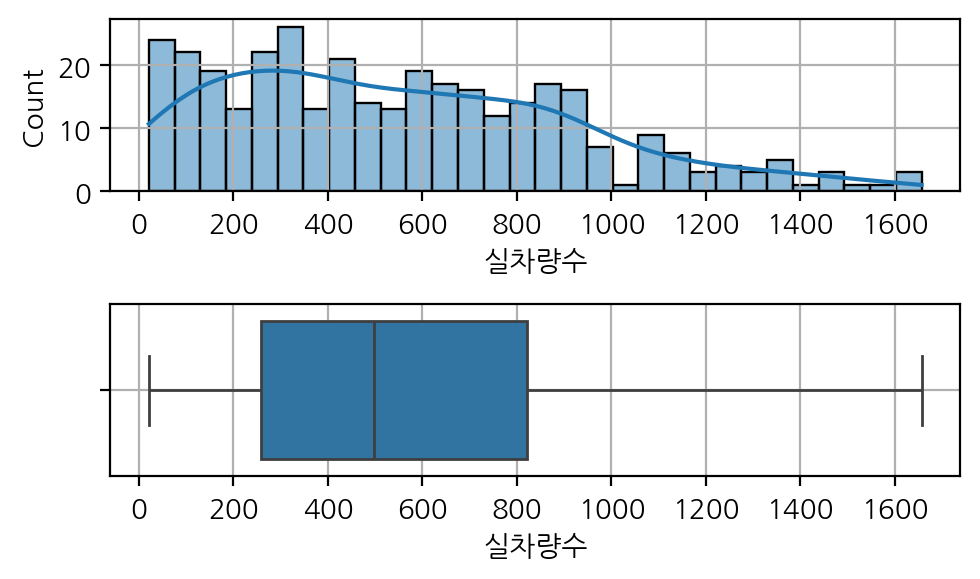

In [12]:
graph_1(apart, '실차량수')
# 의견1: 950대 정도부터 거의 없는 것이 특징으로 보여진다.
# 의견2: 그래프 모양과 중앙값보다 평균값이 큰 것으로 보아 실차량수에 큰값이 다수 존재한다.

#### 2) 총세대수

<< 기초통계량 >>


,count,mean,std,min,25%,50%,75%,max
총세대수,345.0,546.75942,432.359538,1.0,178.0,491.0,853.0,2289.0


<< 그래프 >>


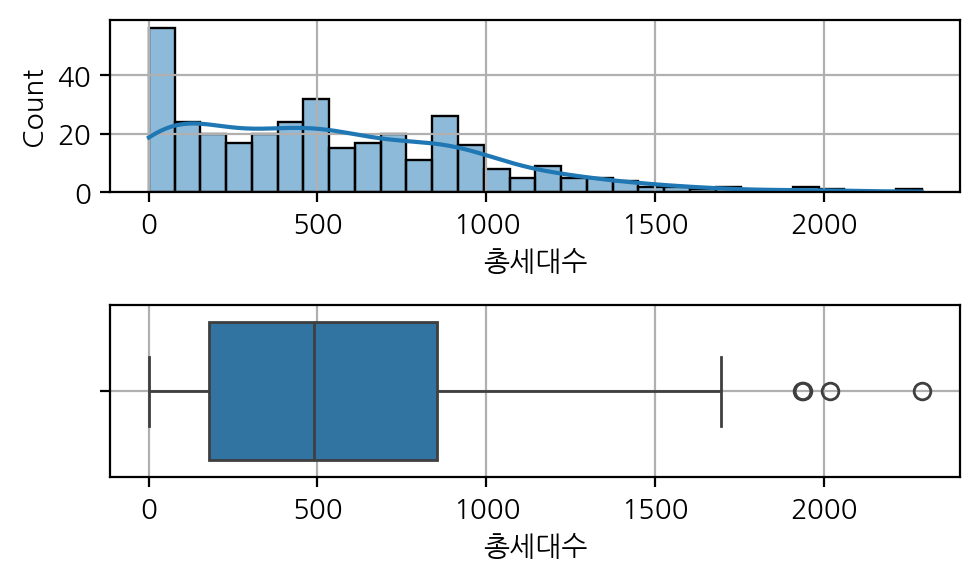

In [13]:
graph_1(apart, '총세대수')
# 의견1: 총세대수의 평균은 546세대 정도이다.
# 의견2: 총세대수와 실차량수의 그래프 모양이 비슷한 것으로 보여 양의 상관관계를 가질 것으로 예상된다.
# 의견3: 총세대수가 10이하인 값들 확인이 필요해 보인다. -> 10개 존재

#### 3) 총면적

<< 기초통계량 >>


,count,mean,std,min,25%,50%,75%,max
총면적,345.0,37282.661962,29588.197927,68.93,11293.8321,32190.36,56189.9796,150126.8632


<< 그래프 >>


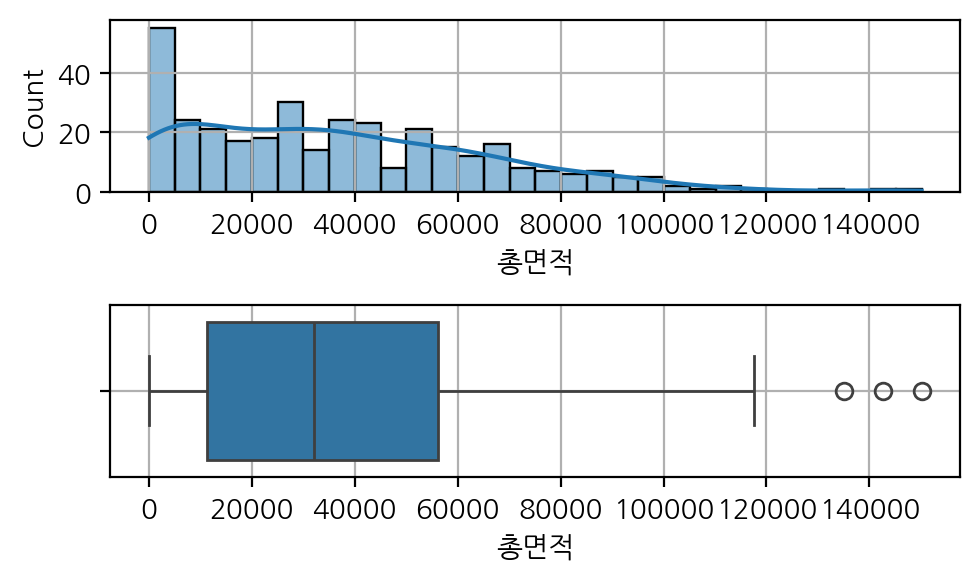

In [15]:
graph_1(apart, '총면적')
# 의견1: 총면적수와 총세대수의 그래프 형태가 유사해 보인다.
# 의견2: 너무 작은 값들 확인이 필요해 보인다.

#### 4) 임대료

<< 기초통계량 >>


,count,mean,std,min,25%,50%,75%,max
임대료,345.0,197729.05021,158760.777669,0.0,112905.0,172000.0,227564.0,950305.0


<< 그래프 >>


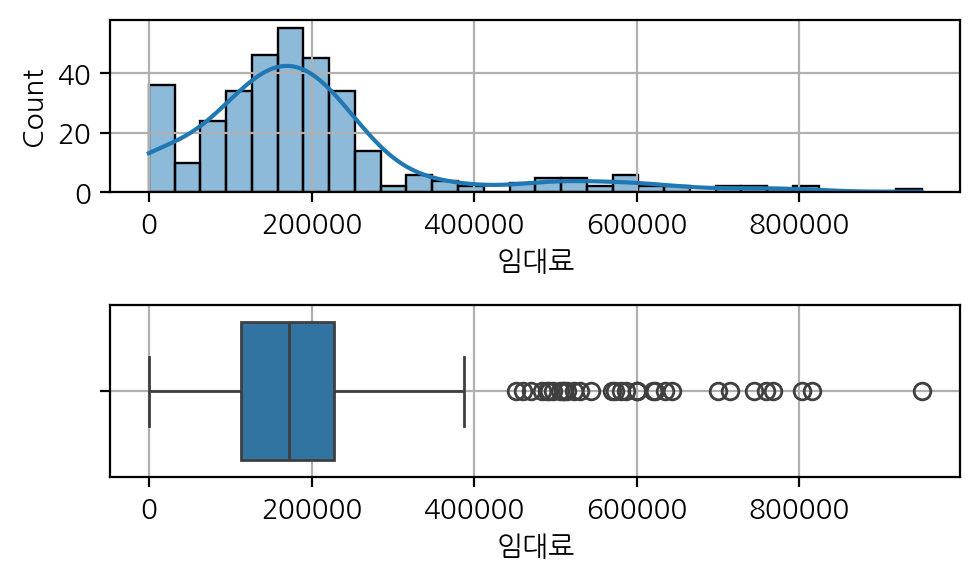

In [16]:
graph_1(apart, '임대료')
# 의견1: 임대료의 이상치는 많은 편으로 보이고 정규분포의 형태를 가진다.
# 의견2: 임대료가 0인 값들의 확인이 필요해 보인다.

#### 5) 임대보증금

<< 기초통계량 >>


,count,mean,std,min,25%,50%,75%,max
임대보증금,345.0,2.382737e+07,2.247481e+07,0.0,1.272491e+07,19308500.0,28377000.0,1.898219e+08


<< 그래프 >>


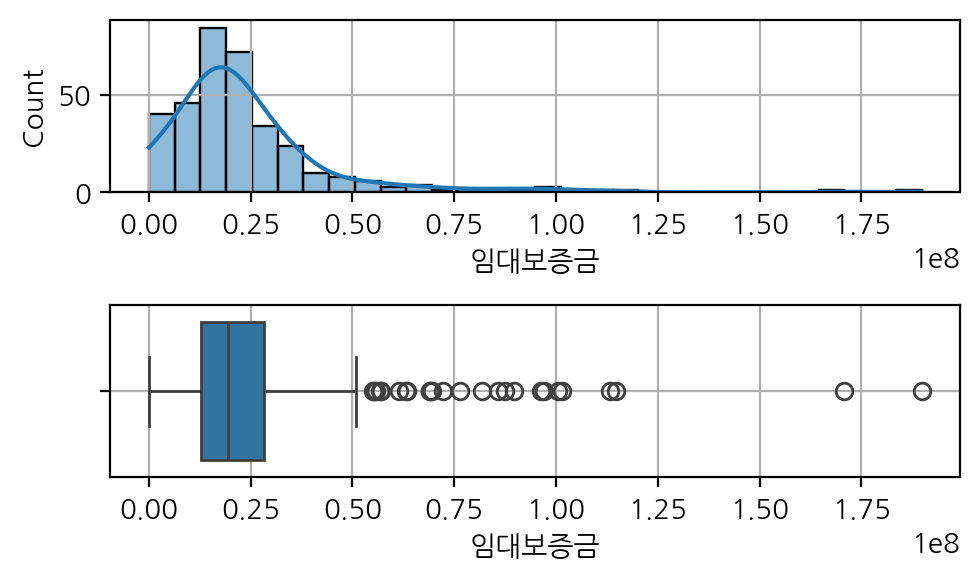

In [17]:
graph_1(apart, '임대보증금')
# 의견1: 임대보증금의 경우 임대료 그래프와 유사한 형태를 보인다.
# 의견2: 임대보증금이 0인 값들의 확인이 필요해 보인다.

### (2) 범주형 변수

- 대상: '지역', '건물형태', '난방방식', '승강기설치여부'
- sns.countplot() 함수 등을 사용해 데이터 분포를 확인합니다.
- 반복되는 코드는 함수를 만들어 사용하면 편리합니다.

In [18]:
# 함수 만들기
def graph_2(data, var):

    plt.figure(figsize=(5,3))
    sns.countplot(x=var, data=data)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

#### 1) 지역

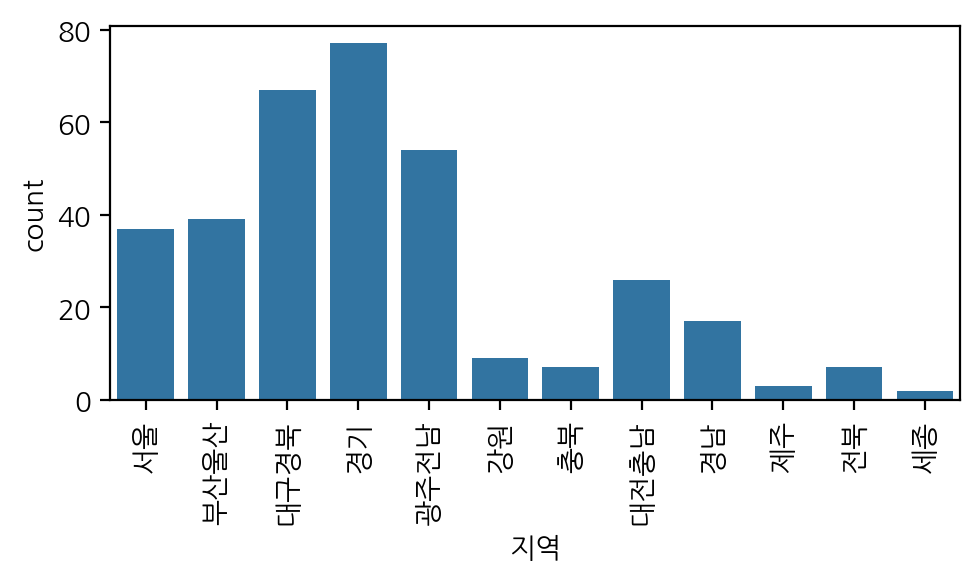

In [19]:
graph_2(apart, '지역')
# 의견: 경기, 대구경북 지역에 주택 공급이 많았다.

#### 2) 건물형태

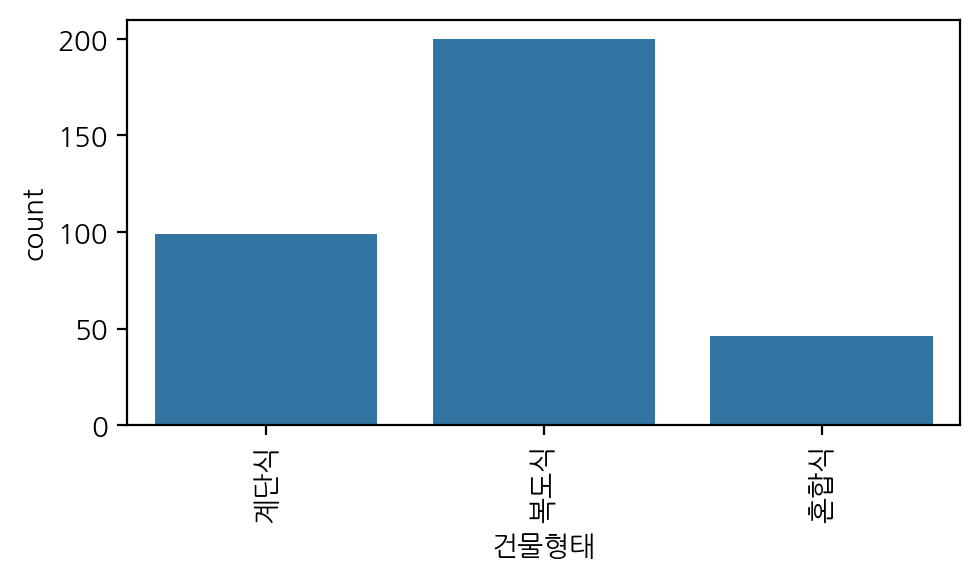

In [20]:
graph_2(apart, '건물형태')
# 의견: 건물의 형태는 복도식이 과반수 이상을 차지했다.

#### 3) 난방방식

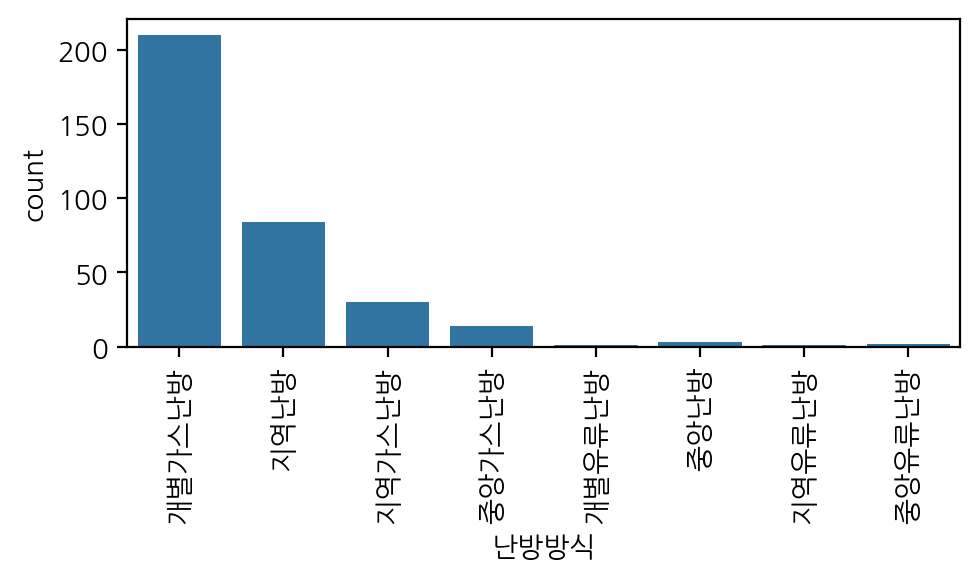

In [21]:
graph_2(apart, '난방방식')
# 의견: 난방방식은 개별가스난방이 과반수 이상을 차지했다.

#### 4) 승강기설치여부

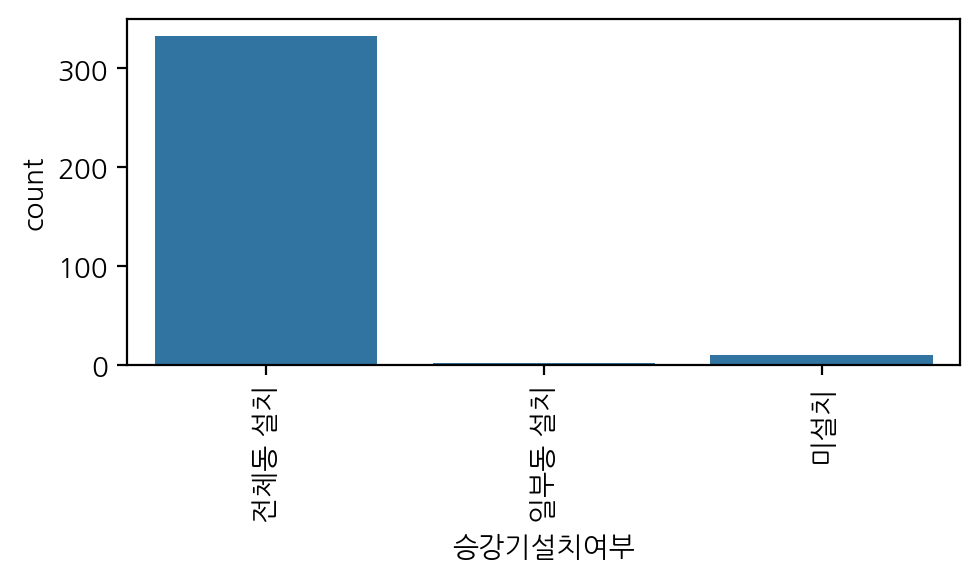

In [22]:
graph_2(apart, '승강기설치여부')
# 의견: 승강기는 거의 대부분의 아파트에 설치되었다.

#### 5) 준공연도

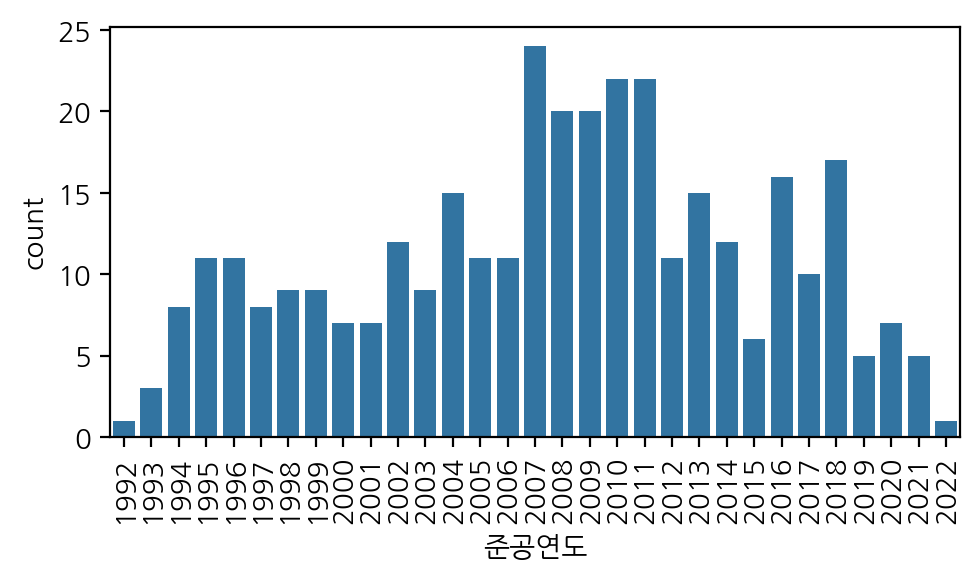

In [23]:
apart['준공연도'] = apart['준공연도'].astype(int)
graph_2(apart, '준공연도')
# 의견: 준공연도는 2007년 ~ 2011년 사이에 가장 많았다.

#### 6) 전용면적구간

- 전용면적구간은 pd.melt() 함수를 사용해 pivot을 해제하여 전용면적구간별 세대수를 분석합니다.

In [24]:
# pd.melt를 사용해 전용면적구간별 세대수 데이터 변환
df_melted = pd.melt(apart, id_vars='단지코드', 
                    value_vars=['소형', '중소형', '중형', '중대형', '대형'], 
                    var_name='전용면적구간', 
                    value_name='세대수')

# 세대수가 0보다 큰 데이터만 필터링
df_melted = df_melted[df_melted['세대수'] > 0]

# 결과 확인
df_melted.head()

,단지코드,전용면적구간,세대수
1,C0002,소형,35
4,C0006,소형,15
125,C0137,소형,26
137,C0149,소형,32
138,C0150,소형,1166


## 4. 이변량 분석

- 숫자형 변수들 간의 상관관계를 분석합니다.
- 숫자형 변수 → 실차량수 상관관계를 분석합니다.    
- 볌주형 변수 → 실차량수 관계를 분석합니다.

### (1) 숫자형 변수들 간의 상관관계

- 숫자형 변수 → 실차량수 상관관계를 분석합니다.    
- 숫자형 변수들 간의 상관관계를 df.corr() 메서드와 sns.heatmap() 함수 등을 사용해 시각화 합니다.

In [25]:
apart.corr(numeric_only=True)

,총세대수,준공연도,실차량수,총면적,소형,중소형,중형,중대형,대형,임대보증금,임대료
총세대수,1.000000,0.085396,0.712475,0.927286,0.373339,0.593583,0.701301,0.097786,0.021784,0.172154,0.203985
준공연도,0.085396,1.000000,0.287266,0.171747,0.120319,-0.176351,0.035409,0.232749,0.229599,0.331838,0.325513
실차량수,0.712475,0.287266,1.000000,0.822183,0.077284,0.202548,0.570997,0.340201,0.339617,0.361867,0.337066
총면적,0.927286,0.171747,0.822183,1.000000,0.174025,0.404220,0.690604,0.312529,0.304870,0.361495,0.368626
소형,0.373339,0.120319,0.077284,0.174025,1.000000,0.154369,-0.062858,-0.058897,-0.084080,-0.087044,-0.062674
중소형,0.593583,-0.176351,0.202548,0.404220,0.154369,1.000000,0.138124,-0.158984,-0.226962,-0.125961,-0.088748
중형,0.701301,0.035409,0.570997,0.690604,-0.062858,0.138124,1.000000,-0.152929,-0.230435,0.069391,0.086936
중대형,0.097786,0.232749,0.340201,0.312529,-0.058897,-0.158984,-0.152929,1.000000,0.458495,0.386101,0.445971
대형,0.021784,0.229599,0.339617,0.304870,-0.084080,-0.226962,-0.230435,0.458495,1.000000,0.501247,0.417160
임대보증금,0.172154,0.331838,0.361867,0.361495,-0.087044,-0.125961,0.069391,0.386101,0.501247,1.000000,0.852839


<Axes: >

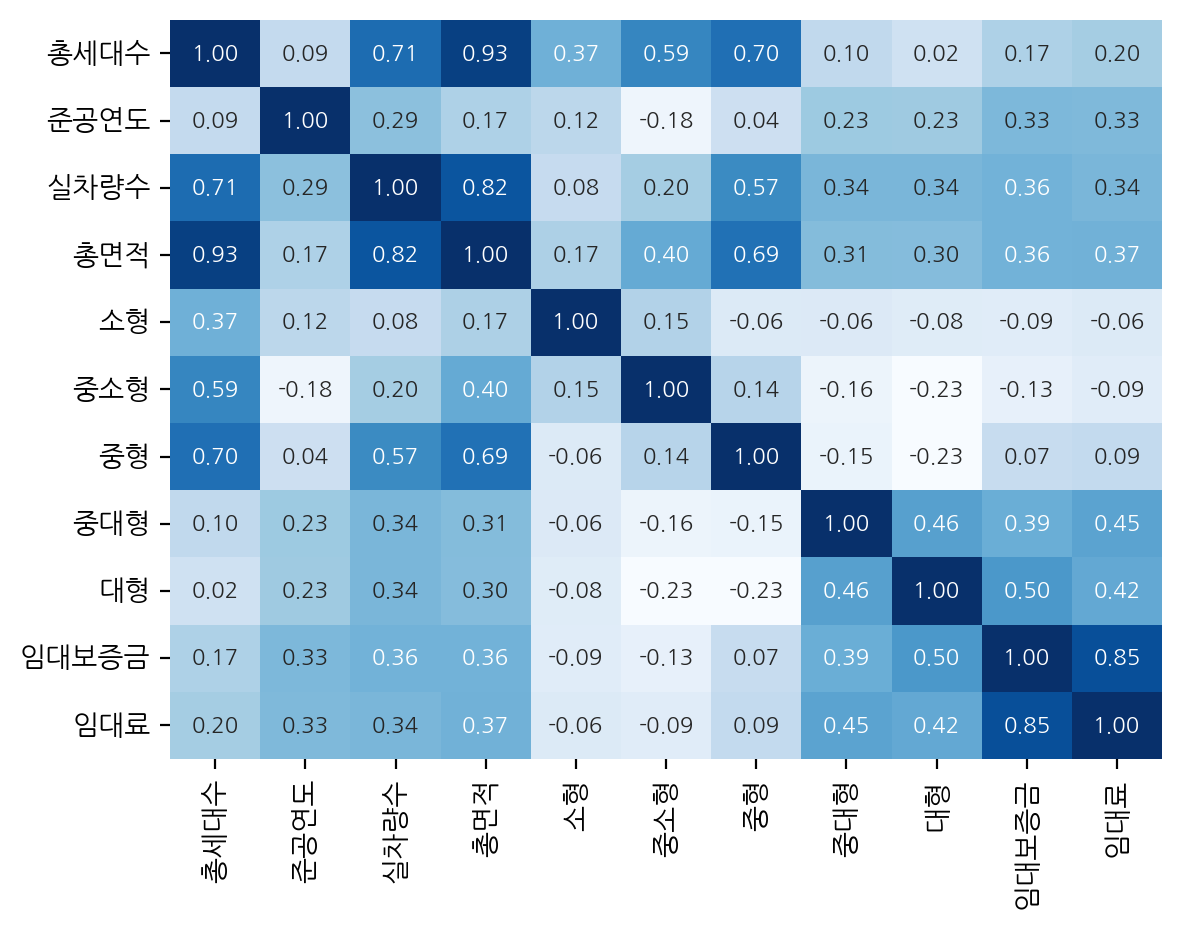

In [26]:
sns.heatmap(apart.corr(numeric_only=True),
           cmap='Blues',
           annot=True,
           fmt='.2f',
           cbar=False,
           annot_kws={'size': 8})

### (2) 숫자형 변수 → 실차량수

- 상관계수가 높은 상위 3~5개 숫자형 변수와 실차량수 관계를 산점도를 시각화해 분석합니다.
- 반복되는 코드는 함수를 만들어 사용하면 편리합니다.

In [27]:
# 함수 만들기
import scipy.stats as spst

def graph_3(x, y):
    
    plt.figure(figsize=(4, 4))
    sns.lmplot(data = apart, x = x, y = y, line_kws={'color': 'red', 'lw': 2})
    plt.grid()
    plt.show()
    print(spst.pearsonr(apart[x], apart[y]))

#### 1) 총면적

<Figure size 400x400 with 0 Axes>

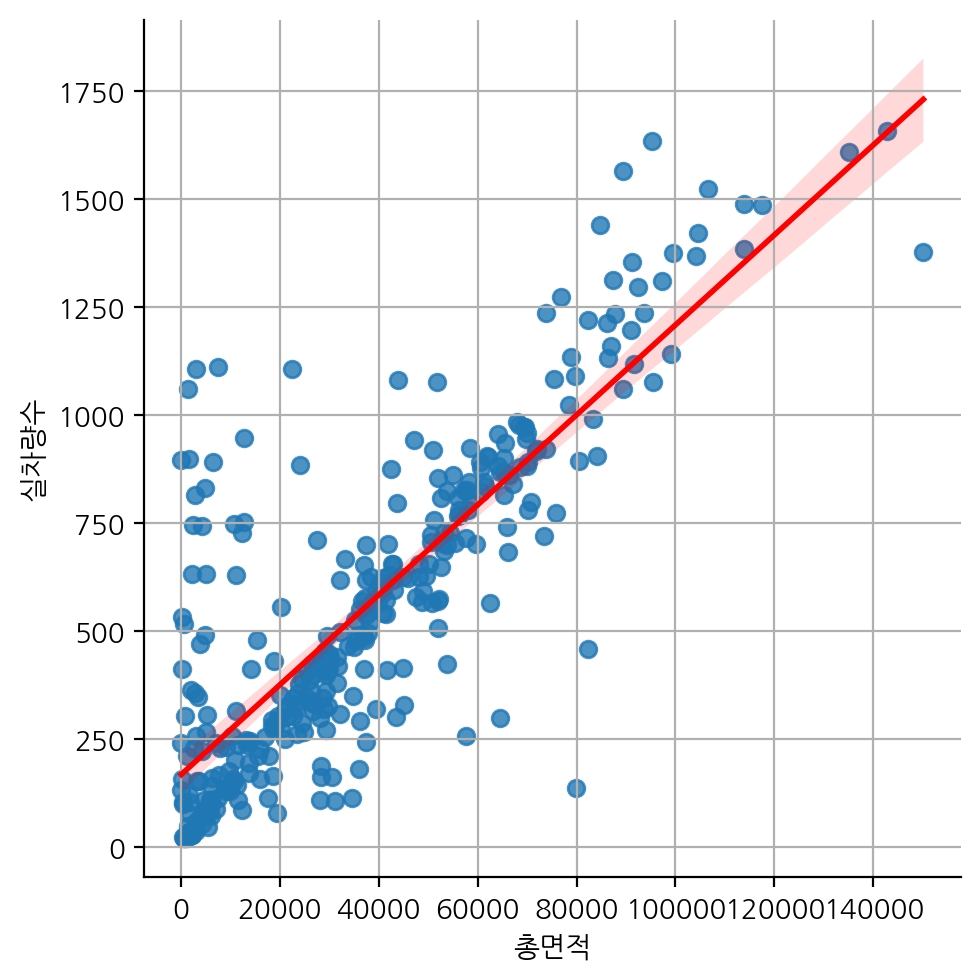

PearsonRResult(statistic=0.8221825549027686, pvalue=6.032798759321441e-86)


In [28]:
graph_3('총면적', '실차량수')
# 실차량수와 총면적은 강한 양의 상관관계를 가지고 있다.

#### 2) 총세대수

<Figure size 400x400 with 0 Axes>

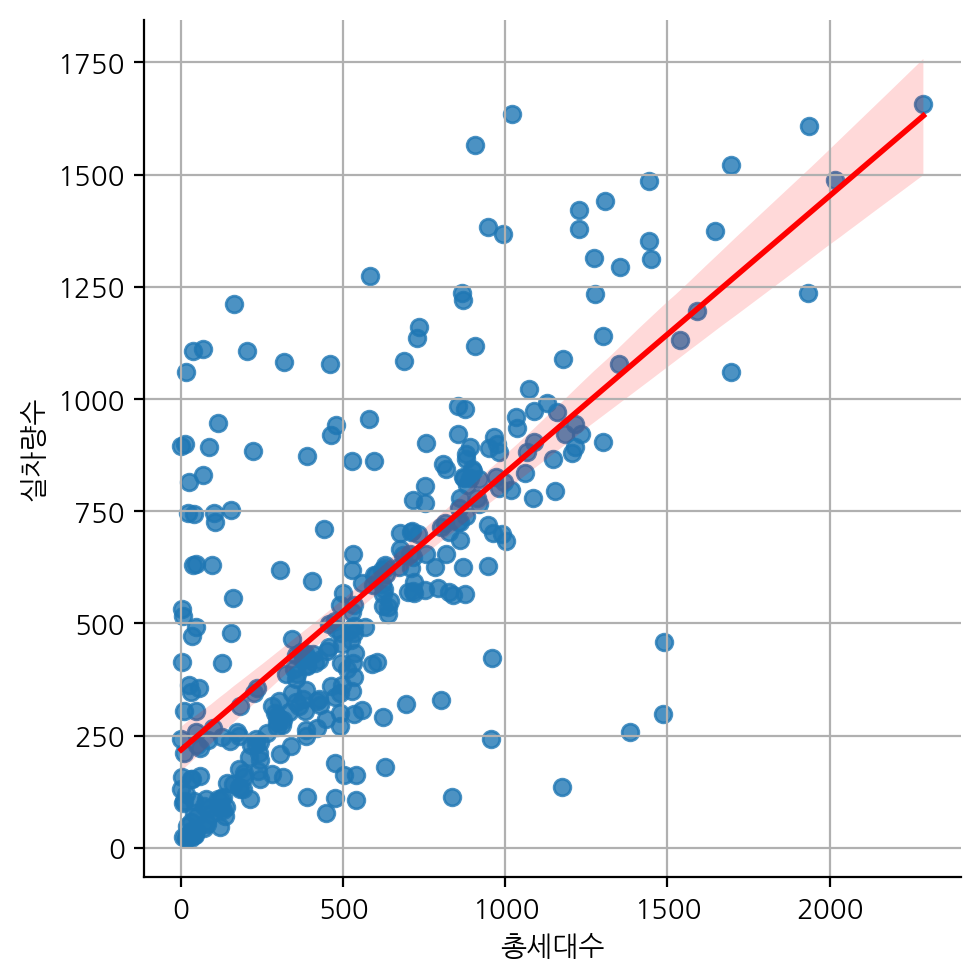

PearsonRResult(statistic=0.7124746462088555, pvalue=1.0221045732952222e-54)


In [29]:
graph_3('총세대수', '실차량수')
# 의견: 실차량수와 총세대수는 강한 양의 상관관계를 가지고 있다.

#### 3) 중형

<Figure size 400x400 with 0 Axes>

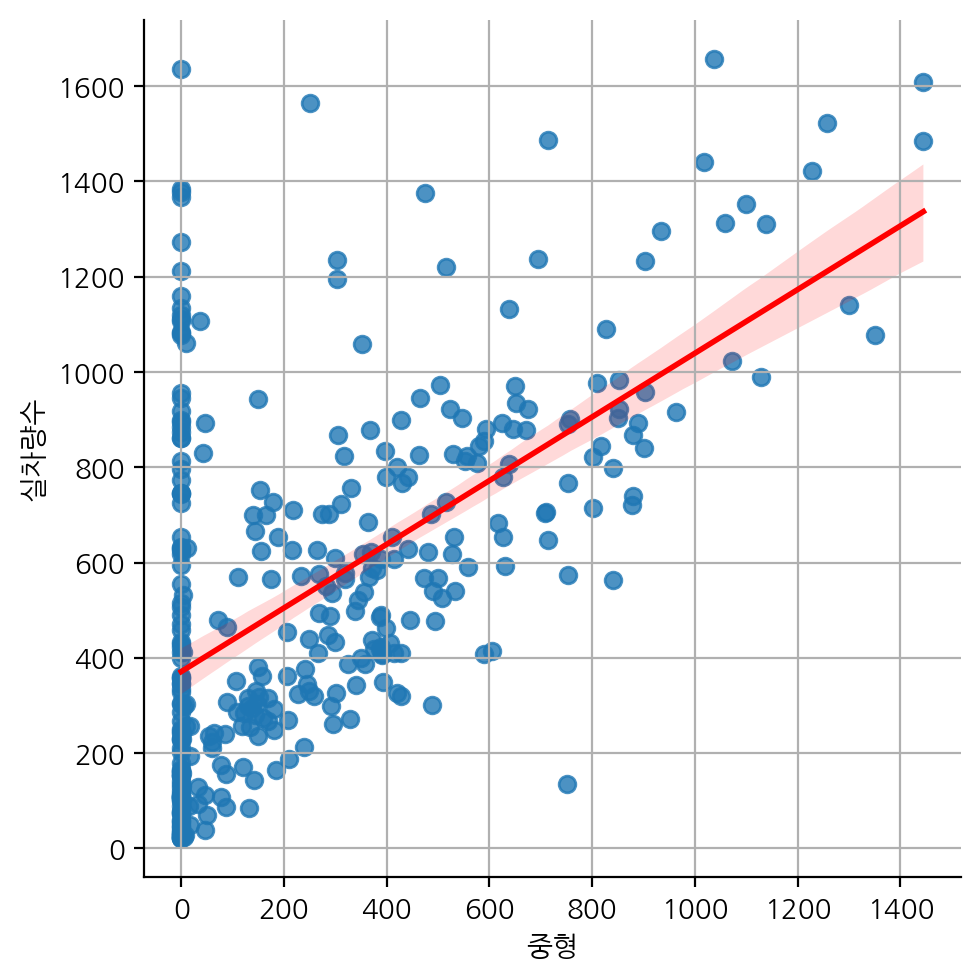

PearsonRResult(statistic=0.5709974871632717, pvalue=3.060104215782182e-31)


In [30]:
graph_3('중형', '실차량수')


### (3) 범주형 변수 → 실차량수

- 범주형 변수 → 실차량수 관계를 분석합니다.
- 대상: '지역', '준공연도', '건물형태', '난방방식', '승강기설치여부'
- 범줏값 별 실차량수 평균을 막대그래프로 시각화해 분석합니다.
- 반복되는 코드는 함수를 만들어 사용하면 편리합니다.

In [31]:
# 함수 만들기
def graph_4(x, y):
    plt.figure(figsize=(5, 3))
    sns.barplot(x=x, y=y, data=apart)
    plt.xticks(rotation=90)
    plt.grid()
    plt.tight_layout()
    plt.show()

    anova = []
    for i in apart[x].unique():
        p_i = apart.loc[apart[x]==i, y]
        anova.append(p_i)
    print(spst.f_oneway(*anova))

#### 1) 지역

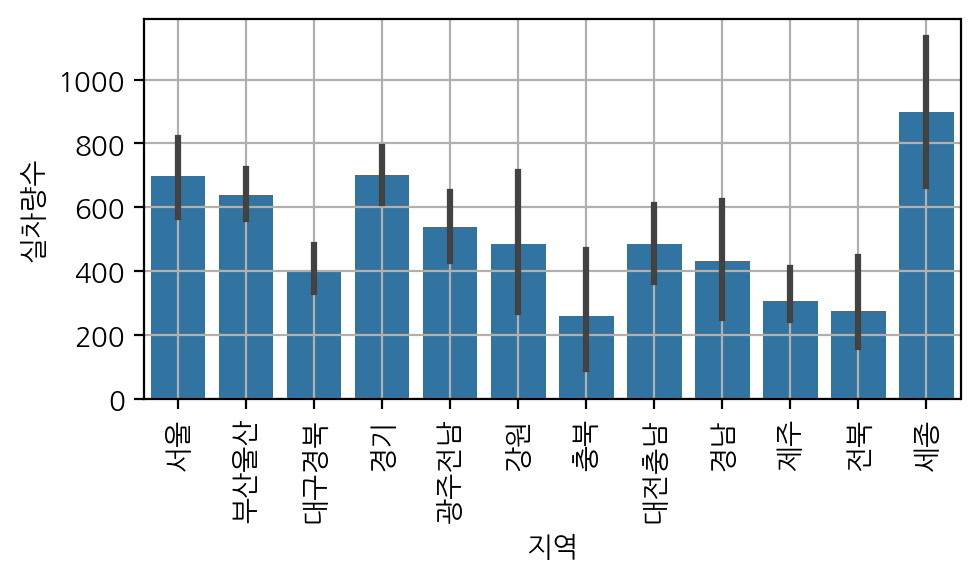

F_onewayResult(statistic=4.451857733965143, pvalue=2.8660069638343555e-06)


In [32]:
graph_4('지역', '실차량수')
# 의견1: 지역간 실차량수의 차이는 유의미하지만 차이값이 크지는 않다.
# 의견2: 세종시는 비교적 최근에 생겨난 신도시라는 배경지식에 의해 교통인프라가 확충되지 않아 실차량의 수가 많은 것으로 예상할 수 있다.

#### 2) 준공연도

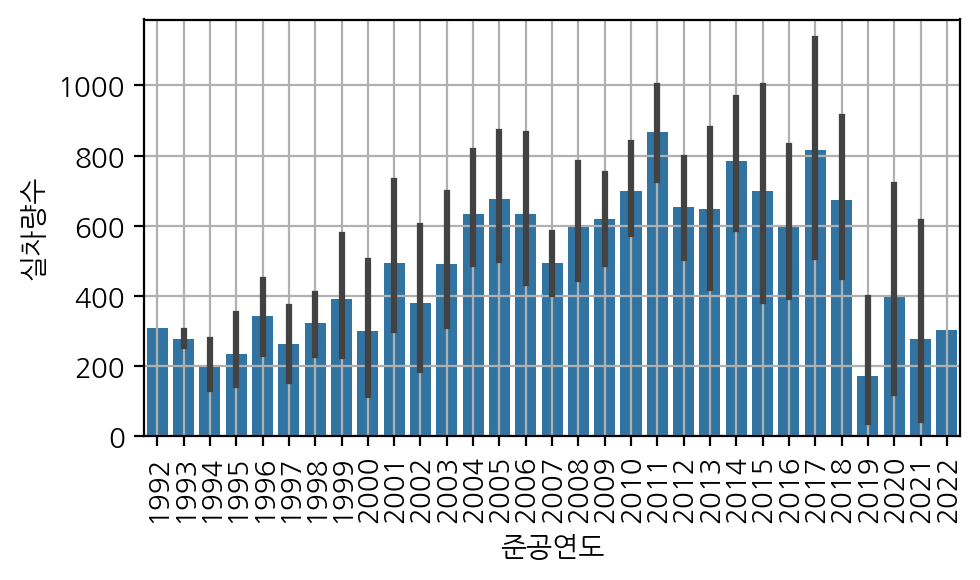

F_onewayResult(statistic=3.3327632896638777, pvalue=5.420679676816041e-08)


In [33]:
graph_4('준공연도', '실차량수')
# 의견: 준공연도별 실차량수의 차이는 유의미하지만 차이값이 크지는 않다.

#### 3) 건물형태

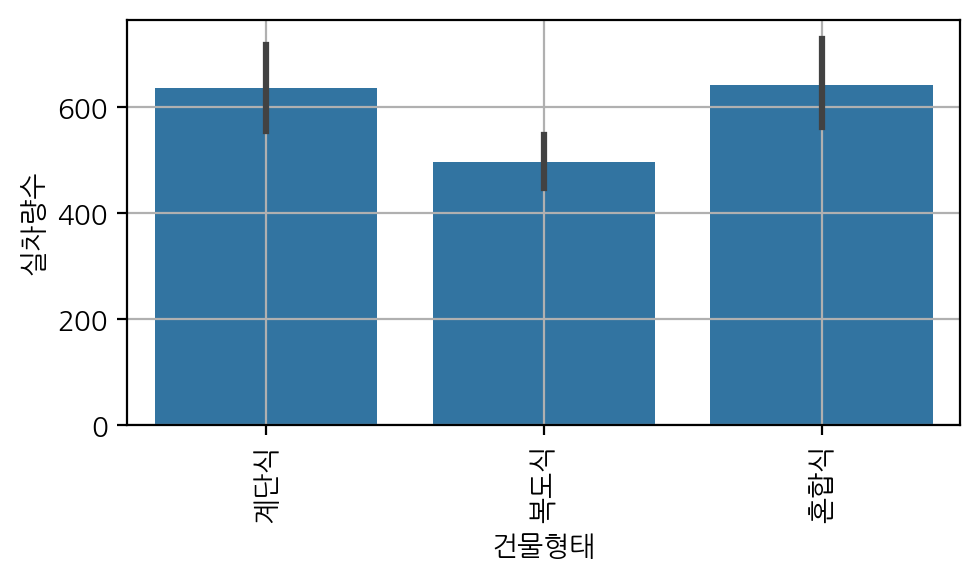

F_onewayResult(statistic=6.07632088862142, pvalue=0.002552061140492482)


In [34]:
graph_4('건물형태', '실차량수')
# 의견: 건물형태별 실차량수의 차이는 유의미하지만 차이값이 크지는 않다.

#### 4) 난방방식

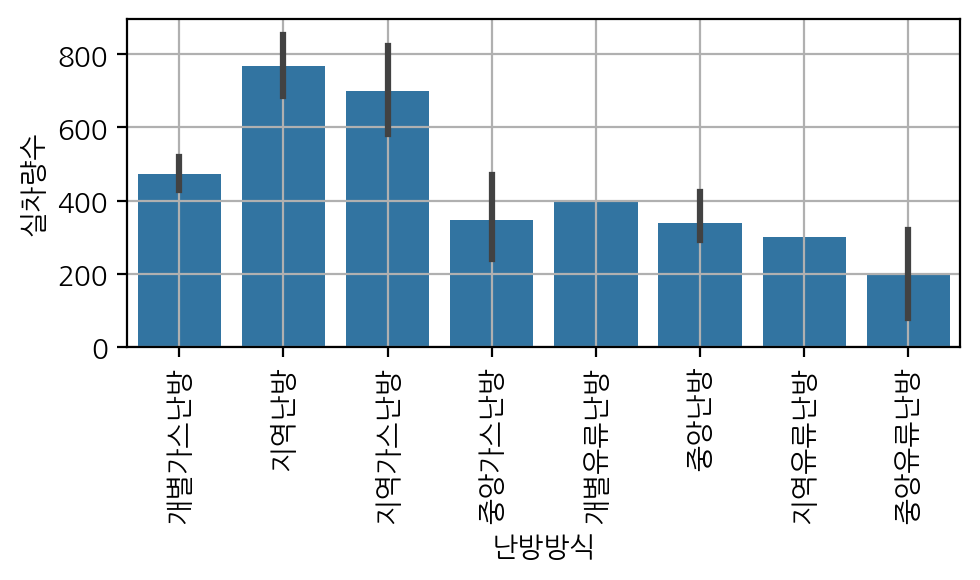

F_onewayResult(statistic=8.188974426537182, pvalue=3.1977629594141447e-09)


In [35]:
graph_4('난방방식', '실차량수')
# 의견: 난방형식별 실차량수의 차이는 유의미하지만 차이값이 크지는 않다.

#### 5) 승강기설치여부

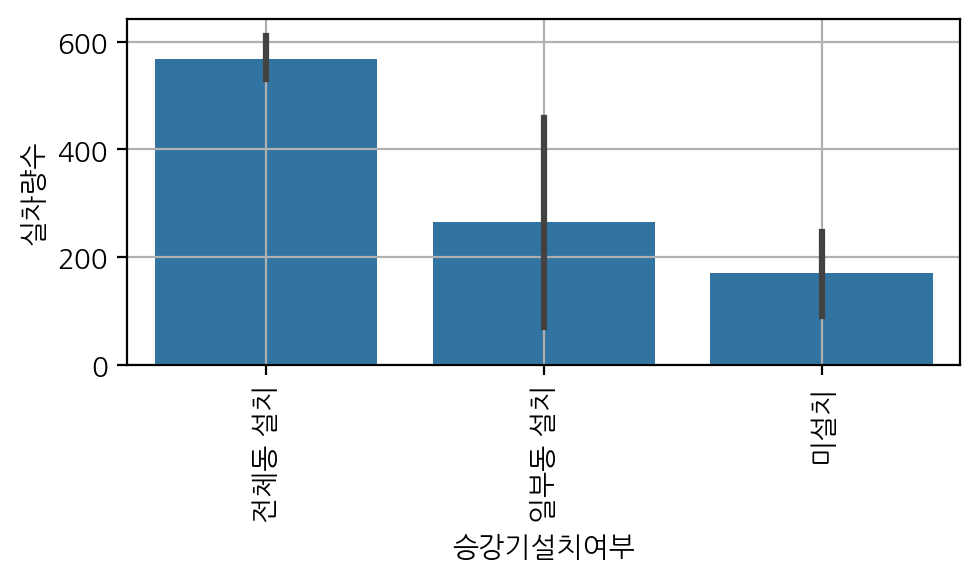

F_onewayResult(statistic=6.27246347210476, pvalue=0.0021119129315533697)


In [36]:
graph_4('승강기설치여부', '실차량수')
# 의견: 승강기설치여부별 실차량수의 차이는 유의미하지만 차이값이 크지는 않다.

## 5. 추가 전처리

- '난방방식', '승강기설치여부' 두 변수에 대해서 적은 수의 범주로 묶는 작업을 진행합니다.
- '단지코드'는 개별적인 값이므로 예측과 관련이 없으니 제거합니다.
- '지역' 변수는 지역별 특성을 고려하기에는 너무 세분화 되어 있고, 특징으로 통합하기 어려우므로 제거합니다.

### (1) 난방방식

- '난방방식' 변수의 값을 다음과 같이 변경하여 세 개의 범줏값만 갖게 합니다.
    - 개별가스난방 → 개별
    - 개별유류난방 → 개별
    - 지역난방 → 지역
    - 지역가스난방 → 지역
    - 지역유류난방 → 지역
    - 중앙가스난방 → 중앙
    - 중앙난방 → 중앙
    - 중앙유류난방 → 중앙

In [52]:
apart['난방방식'] = apart['난방방식'].replace({
    '개별가스난방' : '개별',
    '개별유류난방' : '개별',
    '지역난방' : '지역',
    '지역가스난방' : '지역',
    '지역유류난방' : '지역',
    '중앙가스난방' : '중앙',
    '중앙난방' : '중앙',
    '중앙유류난방' : '중앙'
})

### (2) 승강기설치여부

- '승강기설치여부' 변수의 값을 다음과 같이 변경하여 0, 1 값을 갖게 합니다.
    - 전체동 설치 → 1
    - 일부동 설치 → 0
    - 미설치 → 0

In [53]:
apart['승강기설치여부'] = apart['승강기설치여부'].map({
    '전체동 설치' : 1,
    '일부동 설치' : 0,
    '미설치' : 0})

### (3) 단지코드, 지역 제거

- '단지코드', '지역' 변수를 제거합니다.

In [54]:
drop_cols = ['단지코드', '지역']
apart.drop(columns=drop_cols, inplace=True)

- 최종 데이터를 확인합니다.

In [40]:
apart.head()

,총세대수,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,소형,중소형,중형,중대형,대형,임대보증금,임대료
0,78,2013,계단식,개별,1,109,6023.7683,0,0,78,0,0,5.696200e+07,642930.000000
1,35,2013,복도식,개별,1,35,1569.1668,35,0,0,0,0,6.306200e+07,470100.000000
2,88,2013,계단식,개별,1,88,7180.1396,0,0,88,0,0,7.219000e+07,586540.000000
3,477,2014,복도식,지역,1,943,47058.9273,0,0,150,216,111,1.015167e+08,950305.000000
4,15,2013,복도식,개별,1,21,543.0268,15,0,0,0,0,5.522750e+07,340148.333333


## 6. 데이터 셋 저장

- joblib.dump() 함수를 사용하여 최종 데이터 셋을 파일로 저장합니다.
- 파일 이름은 base_data2.pkl로 합니다.

In [55]:
# 파일로 저장
joblib.dump(apart, path+'base_data2_arch2.pkl')

['base_data2_arch2.pkl']